# Synthetic baseline: EpiLink-Leiden vs. logistic regression vs. TreeCluster

Three clustering approaches compared on the **identical** matched-baseline synthetic
dataset, scored against the **same** SCoVMod ground-truth memberships with **BCubed F1**.

| Approach | Per-pair input | Clustering |
|---|---|---|
| **EpiLink-Leiden** (EDD/EDS/ESD/ESS) | compatibility score | Leiden community detection |
| **Logistic regression-Leiden** (LD/LS) | logistic probability | Leiden community detection |
| **TreeCluster** (this notebook) | **time-calibrated** phylogeny | `max_clade` tree-cut over a time-threshold grid |

The TreeCluster arm mirrors `phylo_cluster_pipeline.ipynb` (the Boston real-data
workflow): a genetic tree is **time-calibrated with TreeTime** so branch lengths are in
calendar years, then TreeCluster cuts it with a threshold in years. Here the genetic
tree is built by neighbour-joining from the simulated genetic distances (instead of
VeryFastTree from an alignment), and the synthetic per-case sampling **days since the
epidemic origin** are converted to calendar dates for TreeTime.

**Fairness protocol**

- Every method sees the same simulated cases. We re-simulate here with the canonical
  seed and **assert** the pair count matches the published baseline.
- EpiLink / regression best-F1 are read from `results/synthetic/baseline_performance.json`
  (best BCubed F1 over the Leiden resolution grid).
- TreeCluster gets the same oracle advantage: best BCubed F1 over a method x
  time-threshold grid.
- TreeCluster yields a partition only, so ranking metrics (AP / PR-Gain / Brier) do not
  apply and are left as `NaN`.

> **Runtime.** FastME builds each genetic tree in seconds; TreeTime (several min/tree at
> ~5000 tips) is the main cost. Set `MAX_CASES` to a small number to smoke-test the whole
> flow, then reset it to `None` for the real, comparable run.

## Step 0 — imports and parameters

In [1]:
import datetime
import io
import json
import subprocess
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# Put the evaluation package *and* its bare-import modules on sys.path
# (the package modules import each other as `from leiden import ...`, etc.).
SRC = Path("src").resolve()
for _p in (str(SRC), str(SRC / "evaluation")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from evaluation.config import build_run_specs, load_config  # noqa: E402
from evaluation.evaluate import _load_tree_template, _reference_memberships  # noqa: E402
from evaluation.models import build_natural_history_parameters, build_linkage_model  # noqa: E402
from evaluation.leiden import build_weighted_graph, run_leiden_partition  # noqa: E402
from evaluation.metrics import bcubed_scores  # noqa: E402
from evaluation.specs import (  # noqa: E402
    PAIRWISE_BOTH_SAMPLED_COLUMN,
    PAIRWISE_CASE_A_COLUMN,
    PAIRWISE_CASE_B_COLUMN,
    PAIRWISE_DETERMINISTIC_DISTANCE_COLUMN,
    PAIRWISE_RELATED_COLUMN,
    PAIRWISE_STOCHASTIC_DISTANCE_COLUMN,
    PAIRWISE_TEMPORAL_DISTANCE_COLUMN,
)
from epilink import (  # noqa: E402
    InfectiousnessToTransmission,
    build_pairwise_case_table,
    simulate_epidemic_dates,
    simulate_genomic_sequences,
)

In [2]:
# ---- paths ----
CONFIG_PATH = "config.yaml"
PERF_JSON = Path("results/synthetic/baseline_performance.json")
OUTDIR = Path("phylo/synthetic")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---- time calibration (mirrors phylo_cluster_pipeline.ipynb) ----
ORIGIN_DATE = datetime.date(2020, 1, 1)  # calendar anchor for synthetic day 0
CLOCK_FILTER = 0  # IQD temporal-outlier filter; 0 keeps every tip (fair comparison)
CLOCK_RATE = None  # None -> TreeTime infers the clock from root-to-tip regression
CLOCK_STD_DEV = None  # TreeTime's relaxed clock stdev; small value -> strict clock (faster, more comparable to FastME)
# ---- genetic tree (FastME, distance-based) ----
FASTME_METHOD = "N"  # N = neighbour-joining, B = BIONJ

# ---- TreeCluster sweep on the DATED tree (threshold in years) ----
# max_clade caps the within-cluster leaf-to-leaf TIME span; calibrate against known
# epi linkage just as in the Boston notebook (which used 7 / 365).
TC_METHODS = ["max_clade", "avg_clade", "single_linkage"]
TC_THRESHOLD_DAYS = np.arange(7.0, 77.0, 7.0)
TC_THRESHOLDS = TC_THRESHOLD_DAYS / 365.0
SINGLETON_OFFSET = 10**7  # unique cluster ids for TreeCluster's -1 singletons

# ---- method-vs-method similarity (EpiLink-Leiden vs TreeCluster, Step 7) ----
# ARI needs hard partitions, so it compares the two methods to each other, not to the
# overlapping ground truth (which stays on BCubed F1 in Steps 5-6).
LEIDEN_RESOLUTIONS = np.round(np.arange(0.1, 1.01, 0.1), 2)
TC_COMPARE_METHOD = "max_clade"  # TreeCluster method used for the agreement heatmap
MIN_EDGE_WEIGHT = 0.0001  # graph sparsification (matches optimal_thresholds.json)
N_RESTARTS_COMPARE = 5  # Leiden restarts per resolution for the comparison sweep

# ---- quick-iteration knob ----
# Cap the number of cases to make NJ + TreeTime fast while debugging. MUST be None for
# the headline comparison (the baseline numbers were computed on every case).
MAX_CASES = None

## Step 1 — reproduce the matched-baseline synthetic data

`evaluate_scenario` is deterministic given the seed, so re-running the simulation
portion regenerates exactly the dataset behind the published EpiLink / regression
numbers. We keep the populated tree because it carries each case's `sample_date`
(integer days since the epidemic origin), which TreeTime needs as calendar dates.

In [3]:
config = load_config(CONFIG_PATH)
rng_seed = int(config.get("rng_seed", 12345))
runs = build_run_specs(config)
baseline = next(
    r for r in runs if r.condition == "matched" and r.scenario_name == "baseline"
)
gen = baseline.generation_parameters
GENOME_LENGTH = int(gen.get("synthetic_genome_length", 5000))

tree = _load_tree_template(baseline.tree_path).copy()
reference = _reference_memberships(baseline.tree_path)  # ground-truth memberships
profile = InfectiousnessToTransmission(
    parameters=build_natural_history_parameters(gen), rng_seed=rng_seed
)
populated = simulate_epidemic_dates(
    transmission_profile=profile,
    tree=tree,
    fraction_sampled=float(gen.get("fraction_sampled", 1.0)),
)
genomic = simulate_genomic_sequences(
    transmission_profile=profile,
    tree=populated,
    genome_length=GENOME_LENGTH,
)
pairwise = build_pairwise_case_table(genomic["packed"], populated)
pairs = pairwise.loc[pairwise[PAIRWISE_BOTH_SAMPLED_COLUMN]].copy()
print(
    f"{len(pairs):,} sampled pairs | "
    f"prevalence {pairs[PAIRWISE_RELATED_COLUMN].mean():.6f} | "
    f"genome length {GENOME_LENGTH}"
)

12,447,555 sampled pairs | prevalence 0.001447 | genome length 5000


In [4]:
perf = json.loads(PERF_JSON.read_text()) if PERF_JSON.exists() else {}

# Case ids are numeric *strings* in the pairwise table; keep them as strings for
# matrix indexing / filtering (matching the columns) and only int() them when
# scoring against the int-keyed ground-truth reference.
case_ids = np.unique(
    np.concatenate(
        [
            pairs[PAIRWISE_CASE_A_COLUMN].to_numpy(),
            pairs[PAIRWISE_CASE_B_COLUMN].to_numpy(),
        ]
    )
)

if MAX_CASES is not None and MAX_CASES < len(case_ids):
    warnings.warn(
        f"MAX_CASES={MAX_CASES}: TreeCluster results are NOT comparable to the "
        "canonical baseline (computed on all cases). Set MAX_CASES=None for the real run."
    )
    rng = np.random.default_rng(rng_seed)
    case_ids = np.sort(rng.choice(case_ids, size=MAX_CASES, replace=False))
    keep = pairs[PAIRWISE_CASE_A_COLUMN].isin(case_ids) & pairs[
        PAIRWISE_CASE_B_COLUMN
    ].isin(case_ids)
    pairs = pairs.loc[keep].copy()
elif perf:
    expected = int(next(iter(perf.values()))["n_pairs"])
    assert len(pairs) == expected, (
        f"Re-simulated pair count {len(pairs):,} != baseline {expected:,}: "
        "seed/config drift means EpiLink/regression numbers are not comparable."
    )
    print(f"integrity OK: matches canonical baseline ({expected:,} pairs)")

print(f"{len(case_ids):,} cases")

integrity OK: matches canonical baseline (12,447,555 pairs)
4,990 cases


## Step 2 — distance matrices (deterministic & stochastic)

The pairwise table already holds both genetic distances; densify them into square
symmetric matrices over the sampled cases. These mirror the EpiLink/regression
*data process* axis (`*D` = deterministic sequences, `*S` = stochastic).

In [5]:
def distance_matrix(pairs, case_ids, dist_col):
    # Densify a long pairwise distance column into a square symmetric matrix.
    # case_ids is sorted, so searchsorted gives exact row/col positions.
    ia = np.searchsorted(case_ids, pairs[PAIRWISE_CASE_A_COLUMN].to_numpy())
    ib = np.searchsorted(case_ids, pairs[PAIRWISE_CASE_B_COLUMN].to_numpy())
    d = pairs[dist_col].to_numpy(dtype=float)
    n = len(case_ids)
    M = np.zeros((n, n), dtype=float)
    M[ia, ib] = d
    M[ib, ia] = d
    return M


DIST_COLS = {
    "deterministic": PAIRWISE_DETERMINISTIC_DISTANCE_COLUMN,
    "stochastic": PAIRWISE_STOCHASTIC_DISTANCE_COLUMN,
}
matrices = {
    name: distance_matrix(pairs, case_ids, col) for name, col in DIST_COLS.items()
}
for name, M in matrices.items():
    print(f"{name:13s} {M.shape}  range [{M.min():.0f}, {M.max():.0f}]")

deterministic (4990, 4990)  range [0, 49]
stochastic    (4990, 4990)  range [0, 52]


## Step 3 — genetic tree (FastME) + calendar dates

FastME builds a distance-based tree (neighbour-joining by default) in seconds and scales
to thousands of tips. We feed it the genetic distances scaled to **substitutions/site**
(raw SNP distance / genome length) so TreeTime can read the branch lengths as divergence.

The `sample_date` on each tree node is an integer count of days since the epidemic
origin; we convert it to a calendar date (`ORIGIN_DATE + days`) and write the
`name,date` CSV TreeTime expects.

In [6]:
def fastme_tree(D, labels, scale, workdir, method="N"):
    # Build a distance tree with FastME (scales to thousands of tips).
    # The matrix is scaled to substitutions/site (SNP / genome length) so the
    # resulting branch lengths are divergence, which TreeTime reads directly.
    workdir = Path(workdir)
    workdir.mkdir(parents=True, exist_ok=True)
    phylip = workdir / "distances.phy"
    tree = workdir / "fastme.nwk"
    scaled = D * scale
    with open(phylip, "w") as handle:  # stream rows to keep memory bounded
        handle.write(f"{len(labels)}\n")
        for i, label in enumerate(labels):
            handle.write(f"{label} ")
            np.savetxt(handle, scaled[i : i + 1], fmt="%.8f")
    subprocess.run(
        ["fastme", "-i", str(phylip), "-o", str(tree), "-m", method],
        capture_output=True,
        text=True,
        check=True,
    )
    return tree


def write_dates(case_ids, populated, origin, path):
    # Convert per-case sample_date (days since origin) to calendar dates for TreeTime.
    names, dates = [], []
    for case_id in case_ids:
        sample_day = populated.nodes[str(case_id)].get("sample_date")
        if sample_day is None:
            continue
        calendar = origin + datetime.timedelta(days=int(round(float(sample_day))))
        names.append(str(case_id))
        dates.append(calendar.isoformat())
    frame = pd.DataFrame({"name": names, "date": dates})
    frame.to_csv(path, index=False)
    return frame


dates_csv = OUTDIR / "dates.csv"
dates_frame = write_dates(case_ids, populated, ORIGIN_DATE, dates_csv)
print(
    f"{len(dates_frame)} dated tips: "
    f"{dates_frame['date'].min()} .. {dates_frame['date'].max()}"
)

# FastME (~minutes per tree at ~5000 tips) is reused if already built. Caching only
# applies to the canonical run; any MAX_CASES subsample always rebuilds.
genetic_newicks = {}
for name, M in matrices.items():
    cached = OUTDIR / f"fastme_{name}" / "fastme.nwk"
    if cached.exists() and MAX_CASES is None:
        genetic_newicks[name] = cached
        print(f"{name:13s} FastME tree (cached) -> {cached}")
        continue
    t0 = time.time()
    genetic_newicks[name] = fastme_tree(
        M, case_ids, 1.0 / GENOME_LENGTH, OUTDIR / f"fastme_{name}", FASTME_METHOD
    )
    print(
        f"{name:13s} FastME tree -> {genetic_newicks[name]}  ({time.time() - t0:.0f}s)"
    )

4990 dated tips: 2020-01-18 .. 2020-07-14
deterministic FastME tree (cached) -> phylo/synthetic/fastme_deterministic/fastme.nwk
stochastic    FastME tree (cached) -> phylo/synthetic/fastme_stochastic/fastme.nwk


## Step 4 — time-calibrate with TreeTime

TreeTime reroots by root-to-tip regression and rescales branch lengths into calendar
years. With `--sequence-length` (and no alignment) it treats the NJ branch lengths as
divergence and just fits the molecular clock + node times — exactly the calibration
step of the Boston notebook. The dated NEXUS is converted to Newick with `gotree`, as
TreeCluster reads Newick.

In [7]:
def time_calibrate(
    genetic_nwk, dates_csv, outdir, seq_length, clock_filter, clock_rate, clock_std_dev
):
    # NJ genetic tree (+ dates) -> TreeTime dated tree -> Newick (years).
    outdir = Path(outdir)
    cmd = [
        "treetime",
        "--tree",
        str(genetic_nwk),
        "--dates",
        str(dates_csv),
        "--sequence-length",
        str(int(seq_length)),
        "--clock-filter",
        str(clock_filter),
        "--outdir",
        str(outdir),
    ]
    if clock_rate is not None:
        cmd += ["--clock-rate", str(clock_rate)]
    if clock_std_dev is not None:
        cmd += ["--clock-std-dev", str(clock_std_dev)]
    subprocess.run(cmd, capture_output=True, text=True, check=True)
    nexus = outdir / "timetree.nexus"
    newick = outdir / "timetree.nwk"
    subprocess.run(
        [
            "gotree",
            "reformat",
            "newick",
            "-i",
            str(nexus),
            "-f",
            "nexus",
            "-o",
            str(newick),
        ],
        capture_output=True,
        text=True,
        check=True,
    )
    return newick


# TreeTime (~minutes per tree) is reused if already calibrated. Caching only applies to
# the canonical run; any MAX_CASES subsample always recalibrates.
dated_newicks = {}
for name, genetic_nwk in genetic_newicks.items():
    dated_path = OUTDIR / f"treetime_{name}" / "timetree.nwk"
    if dated_path.exists() and MAX_CASES is None:
        dated_newicks[name] = dated_path
        print(f"{name:13s} dated tree (cached) -> {dated_path}")
        continue
    t0 = time.time()
    dated = time_calibrate(
        genetic_nwk,
        dates_csv,
        OUTDIR / f"treetime_{name}",
        GENOME_LENGTH,
        CLOCK_FILTER,
        CLOCK_RATE,
        CLOCK_STD_DEV,
    )
    dated_newicks[name] = dated
    clock = OUTDIR / f"treetime_{name}" / "molecular_clock.txt"
    rate = clock.read_text().strip().splitlines() if clock.exists() else []
    print(f"{name:13s} dated tree -> {dated}  ({time.time() - t0:.0f}s)")
    for line in rate:
        if "rate" in line or "r^2" in line:
            print("   ", line.strip())

deterministic dated tree (cached) -> phylo/synthetic/treetime_deterministic/timetree.nwk
stochastic    dated tree (cached) -> phylo/synthetic/treetime_stochastic/timetree.nwk


## Step 5 — TreeCluster sweep on the dated tree

Run TreeCluster over a method x **time-threshold** grid on each dated tree and score
every partition with BCubed F1 against the same ground-truth reference. TreeCluster's
`-1` singletons each become their own unique cluster id, matching how Leiden's
unclustered tips are treated under BCubed.

In [8]:
def run_treecluster(newick_path, threshold, method):
    proc = subprocess.run(
        ["TreeCluster.py", "-i", str(newick_path), "-t", str(threshold), "-m", method],
        capture_output=True,
        text=True,
        check=True,
    )
    df = pd.read_csv(io.StringIO(proc.stdout), sep="\t")
    df.columns = ["SequenceName", "ClusterNumber"]
    return df


def treecluster_memberships(df):
    # Map TreeCluster output to {case_id: {cluster_id}}; -1 -> unique singleton.
    pred = {}
    singleton = SINGLETON_OFFSET
    for name, cid in zip(df["SequenceName"], df["ClusterNumber"]):
        cid = int(cid)
        if cid == -1:
            pred[int(name)] = {singleton}
            singleton += 1
        else:
            pred[int(name)] = {cid}
    return pred


rows = []
for name, path in dated_newicks.items():
    sweep_path = OUTDIR / "treecluster_sweep.parquet"
    if sweep_path.exists() and MAX_CASES is None:
        print(f"{name:13s} TreeCluster sweep (cached) -> {sweep_path}")
        rows.extend(pd.read_parquet(sweep_path).to_dict("records"))
        continue
    for method in TC_METHODS:
        for t_years, t_days in zip(TC_THRESHOLDS, TC_THRESHOLD_DAYS):
            df = run_treecluster(path, float(t_years), method)
            try:
                precision, recall, f1 = bcubed_scores(
                    treecluster_memberships(df), reference
                )
            except ValueError:
                continue
            clustered = df["ClusterNumber"] != -1
            rows.append(
                {
                    "data_process": name,
                    "method": method,
                    "threshold_days": float(t_days),
                    "threshold_years": float(t_years),
                    "bcubed_precision": precision,
                    "bcubed_recall": recall,
                    "bcubed_f1": f1,
                    "n_clusters": int(df.loc[clustered, "ClusterNumber"].nunique()),
                    "n_singletons": int((~clustered).sum()),
                }
            )

sweep = pd.DataFrame(rows)
sweep.to_parquet(OUTDIR / "treecluster_sweep.parquet", index=False)
print(f"{len(sweep)} (data x method x threshold) evaluations")
sweep.sort_values("bcubed_f1", ascending=False).head(10)

deterministic TreeCluster sweep (cached) -> phylo/synthetic/treecluster_sweep.parquet
stochastic    TreeCluster sweep (cached) -> phylo/synthetic/treecluster_sweep.parquet
2880 (data x method x threshold) evaluations


,data_process,method,threshold_days,threshold_years,bcubed_precision,bcubed_recall,bcubed_f1,n_clusters,n_singletons
1959,stochastic,avg_clade,20.0,0.054795,0.615431,0.566378,0.589886,637,1634
429,stochastic,avg_clade,20.0,0.054795,0.615431,0.566378,0.589886,637,1634
159,stochastic,avg_clade,20.0,0.054795,0.615431,0.566378,0.589886,637,1634
609,stochastic,avg_clade,20.0,0.054795,0.615431,0.566378,0.589886,637,1634
2229,stochastic,avg_clade,20.0,0.054795,0.615431,0.566378,0.589886,637,1634
969,stochastic,avg_clade,20.0,0.054795,0.615431,0.566378,0.589886,637,1634
2409,stochastic,avg_clade,20.0,0.054795,0.615431,0.566378,0.589886,637,1634
1419,stochastic,avg_clade,20.0,0.054795,0.615431,0.566378,0.589886,637,1634
879,stochastic,avg_clade,20.0,0.054795,0.615431,0.566378,0.589886,637,1634
339,stochastic,avg_clade,20.0,0.054795,0.615431,0.566378,0.589886,637,1634


## Step 6 — headline comparison

Best TreeCluster per data process alongside the canonical EpiLink-Leiden and
logistic-regression-Leiden numbers.

In [9]:
tc_best = (
    sweep.sort_values("bcubed_f1", ascending=False)
    .groupby("data_process", as_index=False)
    .first()
)
tc_rows = [
    {
        "model": f"TreeCluster ({row.data_process})",
        "family": "TreeCluster",
        "data_process": row.data_process,
        "clustering": "tree-cut (dated)",
        "best_f1": row.bcubed_f1,
        "detail": f"{row.method} @ {row.threshold_days:g}d",
        "ap": np.nan,
    }
    for row in tc_best.itertuples()
]

EPILINK = {"EDD", "EDS", "ESD", "ESS"}
DATA_PROC = {
    "EDD": "deterministic",
    "ESD": "deterministic",
    "LD": "deterministic",
    "EDS": "stochastic",
    "ESS": "stochastic",
    "LS": "stochastic",
}
pw_rows = [
    {
        "model": key,
        "family": "EpiLink" if key in EPILINK else "Logistic regression",
        "data_process": DATA_PROC[key],
        "clustering": "Leiden",
        "best_f1": value["best_f1"],
        "detail": f"AP={value['ap']:.3f}",
        "ap": value["ap"],
    }
    for key, value in perf.items()
]

comparison = (
    pd.DataFrame(pw_rows + tc_rows)
    .sort_values("best_f1", ascending=False)
    .reset_index(drop=True)
)
comparison.to_parquet(OUTDIR / "treecluster_comparison.parquet", index=False)
comparison

,model,family,data_process,clustering,best_f1,detail,ap
0,LD,Logistic regression,deterministic,Leiden,0.647290,AP=0.568,0.567922
1,ESD,EpiLink,deterministic,Leiden,0.643841,AP=0.469,0.469325
2,EDD,EpiLink,deterministic,Leiden,0.629347,AP=0.300,0.299579
3,TreeCluster (stochastic),TreeCluster,stochastic,tree-cut (dated),0.589886,avg_clade @ 20d,NaN
4,TreeCluster (deterministic),TreeCluster,deterministic,tree-cut (dated),0.589109,max_clade @ 30d,NaN
5,LS,Logistic regression,stochastic,Leiden,0.572059,AP=0.275,0.275356
6,ESS,EpiLink,stochastic,Leiden,0.558696,AP=0.190,0.190371
7,EDS,EpiLink,stochastic,Leiden,0.495397,AP=0.090,0.090462


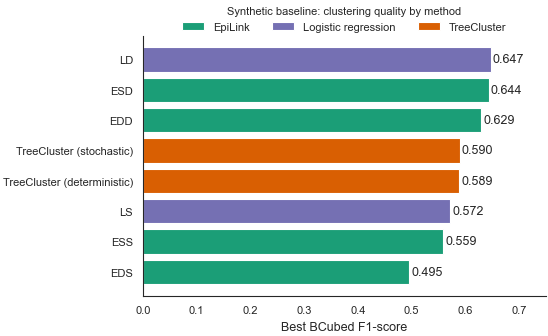

In [10]:
from matplotlib.patches import Patch
from evaluation.plotting import (
    PLOS_WIDTHS_CM,
    cm_to_inch,
    save_plos_figure,
    set_plos_theme,
    add_panel_labels,
)

set_plos_theme()

fig, ax = plt.subplots(
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]) * 0.65,
    )
)
palette = {
    "EpiLink": "#1b9e77",
    "Logistic regression": "#7570b3",
    "TreeCluster": "#d95f02",
}
ordered = comparison.sort_values("best_f1")
ax.barh(
    ordered["model"], ordered["best_f1"], color=[palette[f] for f in ordered["family"]]
)
ax.set_xlabel("Best BCubed F1-score")
# ax.set_title("Synthetic baseline: clustering quality by method")
for y, (value, detail) in enumerate(zip(ordered["best_f1"], ordered["detail"])):
    ax.text(value + 0.004, y, f"{value:.3f}", va="center")

ax.set_xlim(0, 0.75)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

handles = [Patch(facecolor=c) for c in palette.values()]
ax.legend(
    handles, 
    palette.keys(),
    title="Synthetic baseline: clustering quality by method",
    ncol=3, 
    loc="upper center", 
    bbox_to_anchor=(0.5, 1.15),
    )

_ = save_plos_figure(
    fig, 
    "treecluster_comparison", 
    out_dir=OUTDIR,
    save_pdf = True,
    save_png = True,
    save_tiff = True,
    save_eps = False,
    )

## Step 7 — method-vs-method similarity (ARI + AMI)

ARI/AMI needs hard partitions, so it cannot be scored against the **overlapping** SCoVMod
ground truth (Steps 5–6 use BCubed F1 for that). Here we instead measure how much
**EpiLink-Leiden** and **TreeCluster** agree with *each other*, per data process, across
the Leiden resolution × TreeCluster threshold grid:

- EpiLink scores every pair with the matched-baseline **stochastic** scorer on that data
  process's distances, builds the sparsified weighted graph, and runs multi-restart
  Leiden at each resolution.
- TreeCluster cuts the dated tree with `TC_COMPARE_METHOD` (`max_clade`) at each time
  threshold.

Both metrics are computed on the shared cases; each TreeCluster `-1` singleton becomes
its own cluster (matching how Leiden labels every node).

In [11]:
# EpiLink-Leiden partitions per data process across the resolution grid.
epilink_model = build_linkage_model(
    baseline.inference_parameters, mutation_process="stochastic", rng_seed=rng_seed
)
temporal = pairs[PAIRWISE_TEMPORAL_DISTANCE_COLUMN].to_numpy()
source_ids = pairs[PAIRWISE_CASE_A_COLUMN].to_numpy()
target_ids = pairs[PAIRWISE_CASE_B_COLUMN].to_numpy()

leiden_partitions = {}  # {data_process: {resolution: {case_id: cluster}}}
for name, col in DIST_COLS.items():
    scores = np.asarray(
        epilink_model.score_target(
            sample_time_difference=temporal, genetic_distance=pairs[col].to_numpy()
        ),
        dtype=float,
    )
    graph = build_weighted_graph(
        minimum_weight=MIN_EDGE_WEIGHT,
        source_ids=source_ids,
        target_ids=target_ids,
        weights=scores,
        vertex_ids=case_ids,
    )
    per_resolution = {}
    for resolution in LEIDEN_RESOLUTIONS:
        partition, _ = run_leiden_partition(
            graph,
            "weight",
            float(resolution),
            num_restarts=N_RESTARTS_COMPARE,
            rng_seed=rng_seed,
        )
        per_resolution[float(resolution)] = {
            graph.vs[i]["case_id"]: partition.membership[i]
            for i in range(graph.vcount())
        }
    leiden_partitions[name] = per_resolution
    counts = [len(set(per_resolution[float(r)].values())) for r in LEIDEN_RESOLUTIONS]
    print(f"{name:13s} EpiLink-Leiden: {graph.ecount():,} edges | clusters {counts}")

# TreeCluster partitions per data process across the threshold grid (compare method).
# SequenceName is cast to str: numeric case ids would otherwise be read as int64 and
# fail to match the string-keyed Leiden / case_ids.
tc_partitions = {}  # {data_process: {threshold_days: {case_id: cluster}}}
for name, dated in dated_newicks.items():
    per_threshold = {}
    for t_days, t_years in zip(TC_THRESHOLD_DAYS, TC_THRESHOLDS):
        df = run_treecluster(dated, float(t_years), TC_COMPARE_METHOD)
        per_threshold[float(t_days)] = dict(
            zip(df["SequenceName"].astype(str), df["ClusterNumber"].astype(int))
        )
    tc_partitions[name] = per_threshold
print(f"TreeCluster partitions: {TC_COMPARE_METHOD} at {len(TC_THRESHOLD_DAYS)} thresholds")

deterministic EpiLink-Leiden: 1,154,228 edges | clusters [552, 897, 1206, 1578, 2010, 2641, 3514, 4539, 4990, 4990]
stochastic    EpiLink-Leiden: 1,630,609 edges | clusters [637, 962, 1208, 1488, 1839, 2492, 3272, 4334, 4990, 4990]
TreeCluster partitions: max_clade at 10 thresholds


In [ ]:
def _label_vector(partition, shared):
    # Hard-label vector over `shared`; each -1 becomes a unique singleton (for ARI).
    labels, singleton = [], 10**9
    for sample in shared:
        cluster = partition.get(sample, -1)
        if cluster == -1:
            labels.append(singleton)
            singleton += 1
        else:
            labels.append(cluster)
    return labels

similarity = {}  # {data_process: {"ari": DataFrame, "ami": DataFrame}}
res_cols = [f"{r:g}" for r in LEIDEN_RESOLUTIONS]
thr_rows = [f"{d:g}" for d in TC_THRESHOLD_DAYS]
for name in DIST_COLS:
    ari_path = OUTDIR / f"method_similarity_ari_{name}.csv"
    ami_path = OUTDIR / f"method_similarity_ami_{name}.csv"
    if ari_path.exists() and ami_path.exists() and MAX_CASES is None:
        print(f"{name:13s} method similarity (cached) -> {ari_path}, {ami_path}")
        similarity[name] = {
            "ari": pd.read_csv(ari_path, index_col=0),
            "ami": pd.read_csv(ami_path, index_col=0),
        }
        continue
    leiden = leiden_partitions[name]
    treecluster = tc_partitions[name]
    shared = sorted(set(map(str, case_ids)) & set(next(iter(treecluster.values()))))
    leiden_lab = {r: _label_vector(leiden[float(r)], shared) for r in LEIDEN_RESOLUTIONS}
    ari = pd.DataFrame(index=thr_rows, columns=res_cols, dtype=float)
    ami = pd.DataFrame(index=thr_rows, columns=res_cols, dtype=float)
    for days in TC_THRESHOLD_DAYS:
        tc_lab = _label_vector(treecluster[float(days)], shared)
        for r in LEIDEN_RESOLUTIONS:
            ari.loc[f"{days:g}", f"{r:g}"] = adjusted_rand_score(tc_lab, leiden_lab[r])
            ami.loc[f"{days:g}", f"{r:g}"] = adjusted_mutual_info_score(tc_lab, leiden_lab[r])
    similarity[name] = {"ari": ari, "ami": ami}
    ari.to_csv(OUTDIR / f"method_similarity_ari_{name}.csv")
    ami.to_csv(OUTDIR / f"method_similarity_ami_{name}.csv")
    print(
        f"{name:13s} ({len(shared)} shared cases)  "
        f"ARI {ari.to_numpy().min():.3f}..{ari.to_numpy().max():.3f}  "
        f"AMI {ami.to_numpy().min():.3f}..{ami.to_numpy().max():.3f}"
    )

deterministic (4990 shared cases)  ARI 0.000..0.445  AMI 0.000..0.731
stochastic    (4990 shared cases)  ARI 0.000..0.288  AMI 0.000..0.608


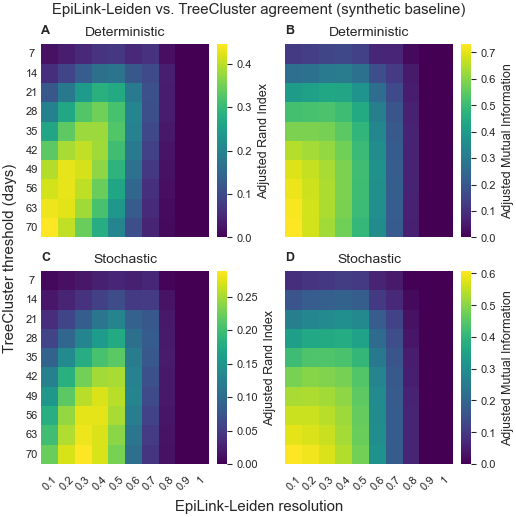

In [15]:
n_processes = len(DIST_COLS)
set_plos_theme()

fig, axes = plt.subplots(
    n_processes, 2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
    ),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for row, name in enumerate(DIST_COLS):
    for col, (metric, label) in enumerate(
        [("ari", "Adjusted Rand Index"), ("ami", "Adjusted Mutual Information")]
    ):
        ax = axes[row][col]
        sns.heatmap(
            similarity[name][metric],
            # annot=True,
            # fmt=".2f",
            cmap="viridis",
            vmin=0,
            cbar_kws={"label": label},
            ax=ax,
        )
        ax.set_title(f"{name.capitalize()}")
for ax in axes[1, 0:].ravel():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="center")

for ax in axes[0:, 0].ravel():
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="center")

fig.supxlabel("EpiLink-Leiden resolution")
fig.supylabel("TreeCluster threshold (days)")
fig.suptitle("EpiLink-Leiden vs. TreeCluster agreement (synthetic baseline)")

add_panel_labels(axes.ravel())
_ = save_plos_figure(
    fig, 
    "method_similarity_synthetic", 
    out_dir=OUTDIR,
    save_pdf = True,
    save_png = True,
    save_tiff = True,
    save_eps = False,
    )

## Notes and caveats

- **Time calibration.** TreeCluster runs on the **dated** tree, so the threshold is a
  clade time-depth in years (here swept as days/365), exactly as in
  `phylo_cluster_pipeline.ipynb`. The synthetic `sample_date` (days since the epidemic
  origin) is anchored to `ORIGIN_DATE`; the absolute anchor is arbitrary and does not
  affect clustering (only the relative spacing matters).
- **Clock signal.** TreeTime infers the molecular clock by root-to-tip regression
  (printed above). If the synthetic signal is weak, pass the known rate via `CLOCK_RATE`.
  `CLOCK_FILTER = 0` keeps every tip so TreeCluster is scored on the same cases as Leiden.
- **Caching.** When `MAX_CASES is None`, existing FastME / TreeTime outputs under
  `phylo/synthetic/` are reused (each tree takes minutes to build); delete those folders
  to force a rebuild.
- **Ground truth vs. method agreement.** The SCoVMod ground truth is *overlapping*, so it
  is scored only with BCubed F1 (Steps 5-6). ARI requires hard partitions, so Step 7 uses
  it to compare EpiLink-Leiden and TreeCluster **to each other**. ARI is chance-corrected;
  BCubed F1 is not (it stays high where one side is all singletons), so read them together.
- **Metric scope.** AP / PR-Gain / Brier need a per-pair ranking, which TreeCluster does
  not produce; only clustering **best BCubed F1** is comparable across all three approaches.
- **Oracle-over-grid.** Best-F1 is taken over a grid for every method (Leiden resolution
  grid for EpiLink/regression; method x time-threshold for TreeCluster).
- **What this isolates.** FastME (NJ) from distances + TreeTime contrasts the *clustering
  paradigm* (graph community detection vs. dated tree-cut). Building the genetic tree from
  the simulated sequences with VeryFastTree instead would additionally fold in
  tree-inference error — a further ablation.
- **Reference.** Every method is scored against the same overlapping SCoVMod ground-truth
  memberships from `_reference_memberships`.